# 2026 NBA Playoff Winning Factors — Exploratory Analysis

This notebook analyzes opponent-relative team performance metrics from the
2026 NBA Playoffs.

The analysis focuses on six metrics:

1. Effective field goal percentage differential
2. Turnover rate advantage
3. Offensive rebound percentage differential
4. Free throw rate differential
5. Three-point attempt rate differential
6. Assist-to-turnover ratio differential

The primary goal is to identify which game-level performance differences were
most strongly associated with winning and evaluate how the New York Knicks
performed in those areas during their championship run.

In [14]:
import pandas as pd
from sqlalchemy import create_engine

In [15]:
DATABASE_URL = "postgresql+psycopg://localhost/nba_playoffs_2026"

engine = create_engine(DATABASE_URL)

In [16]:
query = """
SELECT *
FROM v_team_game_differentials
ORDER BY game_date, game_id, team_abbreviation;
"""

df = pd.read_sql(query, engine)

df.shape

(170, 30)

In [17]:
df.head()

,game_id,game_date,team_id,team_abbreviation,team_name,opponent_team_id,opponent_abbreviation,opponent_name,wl,pts,...,opponent_oreb_pct,opponent_ft_rate,opponent_fg3_attempt_rate,opponent_ast_to_tov_ratio,efg_diff,tov_rate_advantage,oreb_pct_diff,ft_rate_diff,fg3_attempt_rate_diff,ast_to_tov_ratio_diff
0,0042500121,2026-04-18,1610612737,ATL,Atlanta Hawks,1610612752,NYK,New York Knicks,L,102,...,0.157895,0.375000,0.312500,2.000000,-0.032759,-0.006207,0.012318,-0.156609,0.112787,0.083333
1,0042500121,2026-04-18,1610612752,NYK,New York Knicks,1610612737,ATL,Atlanta Hawks,W,113,...,0.170213,0.218391,0.425287,2.083333,0.032759,0.006207,-0.012318,0.156609,-0.112787,-0.083333
2,0042500131,2026-04-18,1610612739,CLE,Cleveland Cavaliers,1610612761,TOR,Toronto Raptors,W,126,...,0.133333,0.492958,0.380282,1.611111,0.029299,0.018317,0.100000,-0.147279,0.014780,-0.199346
3,0042500131,2026-04-18,1610612761,TOR,Toronto Raptors,1610612739,CLE,Cleveland Cavaliers,L,113,...,0.233333,0.345679,0.395062,1.411765,-0.029299,-0.018317,-0.100000,0.147279,-0.014780,0.199346
4,0042500161,2026-04-18,1610612743,DEN,Denver Nuggets,1610612750,MIN,Minnesota Timberwolves,W,116,...,0.152174,0.218391,0.390805,1.615385,-0.028736,-0.001221,0.029644,0.160920,0.022989,0.313187


In [18]:
df.columns.tolist()

['game_id',
 'game_date',
 'team_id',
 'team_abbreviation',
 'team_name',
 'opponent_team_id',
 'opponent_abbreviation',
 'opponent_name',
 'wl',
 'pts',
 'opponent_pts',
 'plus_minus',
 'efg_pct',
 'tov_rate',
 'oreb_pct',
 'ft_rate',
 'fg3_attempt_rate',
 'ast_to_tov_ratio',
 'opponent_efg_pct',
 'opponent_tov_rate',
 'opponent_oreb_pct',
 'opponent_ft_rate',
 'opponent_fg3_attempt_rate',
 'opponent_ast_to_tov_ratio',
 'efg_diff',
 'tov_rate_advantage',
 'oreb_pct_diff',
 'ft_rate_diff',
 'fg3_attempt_rate_diff',
 'ast_to_tov_ratio_diff']

## Data Validation

Before analysis, validate that the analytical dataset has the expected number
of games, team-game rows, outcomes, and no duplicate team-game records.

In [19]:
print("Shape:", df.shape)
print("Unique games:", df["game_id"].nunique())
print("Unique teams:", df["team_id"].nunique())

print("\nWin/Loss counts:")
print(df["wl"].value_counts())

print("\nDuplicate team-game rows:")
print(df.duplicated(subset=["game_id", "team_id"]).sum())

print("\nMissing values:")
print(df.isna().sum())

Shape: (170, 30)
Unique games: 85
Unique teams: 16

Win/Loss counts:
wl
L    85
W    85
Name: count, dtype: int64

Duplicate team-game rows:
0

Missing values:
game_id                      0
game_date                    0
team_id                      0
team_abbreviation            0
team_name                    0
opponent_team_id             0
opponent_abbreviation        0
opponent_name                0
wl                           0
pts                          0
opponent_pts                 0
plus_minus                   0
efg_pct                      0
tov_rate                     0
oreb_pct                     0
ft_rate                      0
fg3_attempt_rate             0
ast_to_tov_ratio             0
opponent_efg_pct             0
opponent_tov_rate            0
opponent_oreb_pct            0
opponent_ft_rate             0
opponent_fg3_attempt_rate    0
opponent_ast_to_tov_ratio    0
efg_diff                     0
tov_rate_advantage           0
oreb_pct_diff                0
ft_

## League-Wide Winner Analysis

Reproduce the SQL winner analysis in Pandas to confirm that the analytical
results remain consistent across both tools.

In [20]:
metric_columns = [
    "efg_diff",
    "tov_rate_advantage",
    "oreb_pct_diff",
    "ft_rate_diff",
    "fg3_attempt_rate_diff",
    "ast_to_tov_ratio_diff",
]

winners = df[df["wl"] == "W"].copy()

winner_average_diffs = (
    winners[metric_columns]
    .mean()
    .round(4)
)

winner_average_diffs

efg_diff                 0.0717
tov_rate_advantage       0.0145
oreb_pct_diff            0.0214
ft_rate_diff             0.0289
fg3_attempt_rate_diff   -0.0115
ast_to_tov_ratio_diff    0.3957
dtype: float64

In [21]:
winner_advantage_pct = (
    (winners[metric_columns] > 0)
    .mean()
    .mul(100)
    .round(1)
)

winner_advantage_pct

efg_diff                 85.9
tov_rate_advantage       62.4
oreb_pct_diff            61.2
ft_rate_diff             57.6
fg3_attempt_rate_diff    40.0
ast_to_tov_ratio_diff    65.9
dtype: float64

## How Often Did Winners Hold Each Advantage?

This chart shows the percentage of 2026 NBA playoff games in which the winning
team held a positive advantage in each metric. This allows the metrics to be
compared on a common scale.

Matplotlib is building the font cache; this may take a moment.


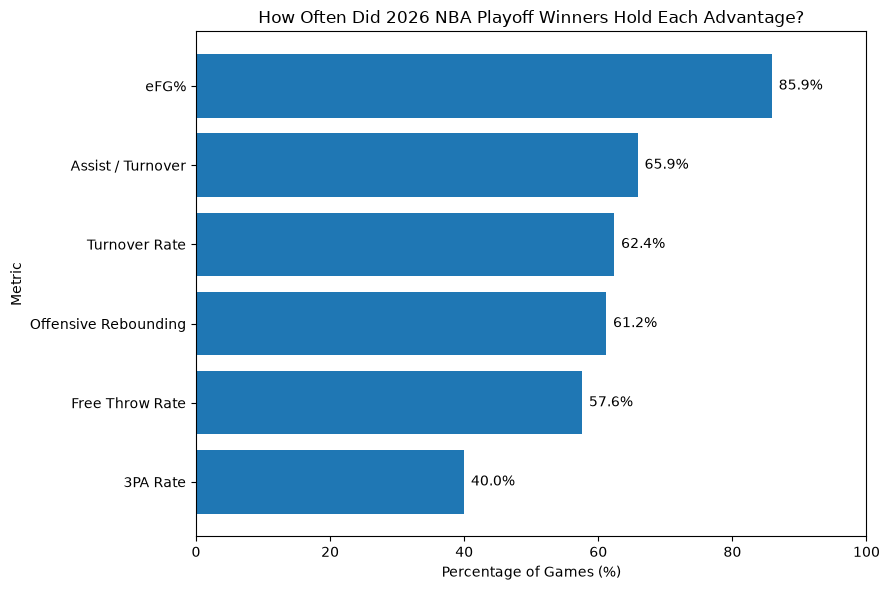

In [22]:
import matplotlib.pyplot as plt

metric_labels = {
    "efg_diff": "eFG%",
    "tov_rate_advantage": "Turnover Rate",
    "oreb_pct_diff": "Offensive Rebounding",
    "ft_rate_diff": "Free Throw Rate",
    "fg3_attempt_rate_diff": "3PA Rate",
    "ast_to_tov_ratio_diff": "Assist / Turnover",
}

plot_data = (
    winner_advantage_pct
    .rename(index=metric_labels)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    plot_data.index,
    plot_data.values
)

ax.set_title(
    "How Often Did 2026 NBA Playoff Winners Hold Each Advantage?"
)
ax.set_xlabel("Percentage of Games (%)")
ax.set_ylabel("Metric")
ax.set_xlim(0, 100)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

## Tableau Data Preparation

Prepare a clean team-game dataset containing the dimensions, outcomes,
performance metrics, and opponent-relative differentials needed for the
Tableau dashboard.

In [23]:
tableau_columns = [
    "game_id",
    "game_date",
    "team_abbreviation",
    "team_name",
    "opponent_abbreviation",
    "opponent_name",
    "wl",
    "pts",
    "opponent_pts",
    "plus_minus",
    "efg_pct",
    "tov_rate",
    "oreb_pct",
    "ft_rate",
    "fg3_attempt_rate",
    "ast_to_tov_ratio",
    "efg_diff",
    "tov_rate_advantage",
    "oreb_pct_diff",
    "ft_rate_diff",
    "fg3_attempt_rate_diff",
    "ast_to_tov_ratio_diff",
]

tableau_df = df[tableau_columns].copy()

tableau_df.shape

(170, 22)

In [24]:
tableau_df.head()

,game_id,game_date,team_abbreviation,team_name,opponent_abbreviation,opponent_name,wl,pts,opponent_pts,plus_minus,...,oreb_pct,ft_rate,fg3_attempt_rate,ast_to_tov_ratio,efg_diff,tov_rate_advantage,oreb_pct_diff,ft_rate_diff,fg3_attempt_rate_diff,ast_to_tov_ratio_diff
0,0042500121,2026-04-18,ATL,Atlanta Hawks,NYK,New York Knicks,L,102,113,-11,...,0.170213,0.218391,0.425287,2.083333,-0.032759,-0.006207,0.012318,-0.156609,0.112787,0.083333
1,0042500121,2026-04-18,NYK,New York Knicks,ATL,Atlanta Hawks,W,113,102,11,...,0.157895,0.375000,0.312500,2.000000,0.032759,0.006207,-0.012318,0.156609,-0.112787,-0.083333
2,0042500131,2026-04-18,CLE,Cleveland Cavaliers,TOR,Toronto Raptors,W,126,113,13,...,0.233333,0.345679,0.395062,1.411765,0.029299,0.018317,0.100000,-0.147279,0.014780,-0.199346
3,0042500131,2026-04-18,TOR,Toronto Raptors,CLE,Cleveland Cavaliers,L,113,126,-13,...,0.133333,0.492958,0.380282,1.611111,-0.029299,-0.018317,-0.100000,0.147279,-0.014780,0.199346
4,0042500161,2026-04-18,DEN,Denver Nuggets,MIN,Minnesota Timberwolves,W,116,105,11,...,0.181818,0.379310,0.413793,1.928571,-0.028736,-0.001221,0.029644,0.160920,0.022989,0.313187


## Export Tableau-Ready Data

Export the cleaned team-game analytical dataset for use in the Tableau
dashboard.

In [25]:
from pathlib import Path

project_root = Path.cwd()

# If the notebook is running from the notebooks folder,
# move up one level to the project root.
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

tableau_team_games_path = processed_dir / "tableau_team_games.csv"

tableau_df.to_csv(
    tableau_team_games_path,
    index=False
)

print("Saved to:", tableau_team_games_path)

Saved to: /Users/jubyaiduddin/Documents/nba-playoff-winning-factors/data/processed/tableau_team_games.csv


In [26]:
export_check = pd.read_csv(
    tableau_team_games_path,
    dtype={"game_id": "string"}
)

print("Exported shape:", export_check.shape)
print("Missing values:", export_check.isna().sum().sum())

export_check.head()

Exported shape: (170, 22)
Missing values: 0


,game_id,game_date,team_abbreviation,team_name,opponent_abbreviation,opponent_name,wl,pts,opponent_pts,plus_minus,...,oreb_pct,ft_rate,fg3_attempt_rate,ast_to_tov_ratio,efg_diff,tov_rate_advantage,oreb_pct_diff,ft_rate_diff,fg3_attempt_rate_diff,ast_to_tov_ratio_diff
0,0042500121,2026-04-18,ATL,Atlanta Hawks,NYK,New York Knicks,L,102,113,-11,...,0.170213,0.218391,0.425287,2.083333,-0.032759,-0.006207,0.012318,-0.156609,0.112787,0.083333
1,0042500121,2026-04-18,NYK,New York Knicks,ATL,Atlanta Hawks,W,113,102,11,...,0.157895,0.375000,0.312500,2.000000,0.032759,0.006207,-0.012318,0.156609,-0.112787,-0.083333
2,0042500131,2026-04-18,CLE,Cleveland Cavaliers,TOR,Toronto Raptors,W,126,113,13,...,0.233333,0.345679,0.395062,1.411765,0.029299,0.018317,0.100000,-0.147279,0.014780,-0.199346
3,0042500131,2026-04-18,TOR,Toronto Raptors,CLE,Cleveland Cavaliers,L,113,126,-13,...,0.133333,0.492958,0.380282,1.611111,-0.029299,-0.018317,-0.100000,0.147279,-0.014780,0.199346
4,0042500161,2026-04-18,DEN,Denver Nuggets,MIN,Minnesota Timberwolves,W,116,105,11,...,0.181818,0.379310,0.413793,1.928571,-0.028736,-0.001221,0.029644,0.160920,0.022989,0.313187


## Team-Level Summary

Aggregate the team-game dataset to one row per playoff team for league-wide
comparison and team ranking in Tableau.

In [27]:
team_summary = (
    df.groupby(
        ["team_abbreviation", "team_name"],
        as_index=False
    )
    .agg(
        games_played=("game_id", "count"),
        wins=("wl", lambda x: (x == "W").sum()),
        avg_efg_diff=("efg_diff", "mean"),
        avg_tov_rate_advantage=("tov_rate_advantage", "mean"),
        avg_oreb_pct_diff=("oreb_pct_diff", "mean"),
        avg_ft_rate_diff=("ft_rate_diff", "mean"),
        avg_fg3_attempt_rate_diff=("fg3_attempt_rate_diff", "mean"),
        avg_ast_to_tov_ratio_diff=("ast_to_tov_ratio_diff", "mean"),
    )
)

team_summary["losses"] = (
    team_summary["games_played"] - team_summary["wins"]
)

team_summary["win_pct"] = (
    team_summary["wins"] / team_summary["games_played"]
)

team_summary.head()

,team_abbreviation,team_name,games_played,wins,avg_efg_diff,avg_tov_rate_advantage,avg_oreb_pct_diff,avg_ft_rate_diff,avg_fg3_attempt_rate_diff,avg_ast_to_tov_ratio_diff,losses,win_pct
0,ATL,Atlanta Hawks,6,2,-0.067505,-0.015586,-0.067219,-0.069451,0.066737,-0.334877,4,0.333333
1,BOS,Boston Celtics,7,3,0.008343,-0.007400,0.082674,-0.007944,0.137865,0.120665,4,0.428571
2,CLE,Cleveland Cavaliers,18,8,-0.007924,-0.013939,-0.008802,0.059529,0.106016,-0.419135,10,0.444444
3,DEN,Denver Nuggets,6,2,-0.030642,0.008419,-0.113429,0.093899,0.040459,-0.113927,4,0.333333
4,DET,Detroit Pistons,14,7,0.012113,-0.006312,0.040813,-0.060855,-0.068954,-0.032090,7,0.500000


In [28]:
team_summary["efg_rank"] = (
    team_summary["avg_efg_diff"]
    .rank(method="min", ascending=False)
    .astype(int)
)

team_summary["tov_rank"] = (
    team_summary["avg_tov_rate_advantage"]
    .rank(method="min", ascending=False)
    .astype(int)
)

team_summary["oreb_rank"] = (
    team_summary["avg_oreb_pct_diff"]
    .rank(method="min", ascending=False)
    .astype(int)
)

team_summary["ft_rate_rank"] = (
    team_summary["avg_ft_rate_diff"]
    .rank(method="min", ascending=False)
    .astype(int)
)

team_summary["ast_tov_rank"] = (
    team_summary["avg_ast_to_tov_ratio_diff"]
    .rank(method="min", ascending=False)
    .astype(int)
)

In [29]:
team_summary = team_summary.round({
    "win_pct": 3,
    "avg_efg_diff": 4,
    "avg_tov_rate_advantage": 4,
    "avg_oreb_pct_diff": 4,
    "avg_ft_rate_diff": 4,
    "avg_fg3_attempt_rate_diff": 4,
    "avg_ast_to_tov_ratio_diff": 4,
})

team_summary = team_summary.sort_values(
    ["wins", "avg_efg_diff"],
    ascending=[False, False]
)

team_summary

,team_abbreviation,team_name,games_played,wins,avg_efg_diff,avg_tov_rate_advantage,avg_oreb_pct_diff,avg_ft_rate_diff,avg_fg3_attempt_rate_diff,avg_ast_to_tov_ratio_diff,losses,win_pct,efg_rank,tov_rank,oreb_rank,ft_rate_rank,ast_tov_rank
8,NYK,New York Knicks,19,16,0.0655,0.0119,0.0575,0.0070,-0.0515,0.3665,3,0.842,1,6,2,6,3
14,SAS,San Antonio Spurs,23,13,0.0499,-0.0091,0.0210,0.0361,0.0159,-0.0908,10,0.565,2,12,6,4,10
9,OKC,Oklahoma City Thunder,15,11,0.0260,0.0319,-0.0136,-0.0164,-0.0096,0.6206,4,0.733,3,2,9,10,1
2,CLE,Cleveland Cavaliers,18,8,-0.0079,-0.0139,-0.0088,0.0595,0.1060,-0.4191,10,0.444,7,13,7,2,15
4,DET,Detroit Pistons,14,7,0.0121,-0.0063,0.0408,-0.0609,-0.0690,-0.0321,7,0.500,5,10,4,14,9
7,MIN,Minnesota Timberwolves,12,6,-0.0344,-0.0020,0.0415,-0.0715,-0.0444,0.0854,6,0.500,10,9,3,16,8
6,LAL,Los Angeles Lakers,10,4,0.0163,-0.0466,-0.0226,0.0590,-0.0437,-0.4037,6,0.400,4,15,10,3,14
11,PHI,Philadelphia 76ers,11,4,-0.0485,0.0008,-0.0897,0.0138,-0.0837,-0.3009,7,0.364,12,8,15,5,12
1,BOS,Boston Celtics,7,3,0.0083,-0.0074,0.0827,-0.0079,0.1379,0.1207,4,0.429,6,11,1,8,6
15,TOR,Toronto Raptors,7,3,-0.0191,0.0143,-0.0424,-0.0134,-0.1191,0.4910,4,0.429,8,5,12,9,2


In [30]:
team_summary.shape

(16, 17)

# Exporting Team Summary


In [31]:
tableau_team_summary_path = (
    processed_dir / "tableau_team_summary.csv"
)

team_summary.to_csv(
    tableau_team_summary_path,
    index=False
)

print("Saved to:", tableau_team_summary_path)

Saved to: /Users/jubyaiduddin/Documents/nba-playoff-winning-factors/data/processed/tableau_team_summary.csv


In [32]:
team_summary_check = pd.read_csv(
    tableau_team_summary_path
)

print("Exported shape:", team_summary_check.shape)
print(
    "Missing values:",
    team_summary_check.isna().sum().sum()
)

Exported shape: (16, 17)
Missing values: 0


In [33]:
league_metric_summary = pd.DataFrame({
    "metric": [
        "eFG%",
        "Turnover Rate",
        "Offensive Rebounding",
        "Free Throw Rate",
        "3PA Rate",
        "Assist / Turnover",
    ],
    "avg_winner_differential": [
        winner_average_diffs["efg_diff"],
        winner_average_diffs["tov_rate_advantage"],
        winner_average_diffs["oreb_pct_diff"],
        winner_average_diffs["ft_rate_diff"],
        winner_average_diffs["fg3_attempt_rate_diff"],
        winner_average_diffs["ast_to_tov_ratio_diff"],
    ],
    "pct_winners_with_advantage": [
        winner_advantage_pct["efg_diff"],
        winner_advantage_pct["tov_rate_advantage"],
        winner_advantage_pct["oreb_pct_diff"],
        winner_advantage_pct["ft_rate_diff"],
        winner_advantage_pct["fg3_attempt_rate_diff"],
        winner_advantage_pct["ast_to_tov_ratio_diff"],
    ],
})

league_metric_summary

,metric,avg_winner_differential,pct_winners_with_advantage
0,eFG%,0.0717,85.9
1,Turnover Rate,0.0145,62.4
2,Offensive Rebounding,0.0214,61.2
3,Free Throw Rate,0.0289,57.6
4,3PA Rate,-0.0115,40.0
5,Assist / Turnover,0.3957,65.9


In [34]:
tableau_winner_metrics_path = (
    processed_dir / "tableau_winner_metrics.csv"
)

league_metric_summary.to_csv(
    tableau_winner_metrics_path,
    index=False
)

print("Saved to:", tableau_winner_metrics_path)

Saved to: /Users/jubyaiduddin/Documents/nba-playoff-winning-factors/data/processed/tableau_winner_metrics.csv


In [35]:
winner_metrics_check = pd.read_csv(
    tableau_winner_metrics_path
)

print("Exported shape:", winner_metrics_check.shape)
print(
    "Missing values:",
    winner_metrics_check.isna().sum().sum()
)

winner_metrics_check

Exported shape: (6, 3)
Missing values: 0


,metric,avg_winner_differential,pct_winners_with_advantage
0,eFG%,0.0717,85.9
1,Turnover Rate,0.0145,62.4
2,Offensive Rebounding,0.0214,61.2
3,Free Throw Rate,0.0289,57.6
4,3PA Rate,-0.0115,40.0
5,Assist / Turnover,0.3957,65.9
